In [1]:
import pandas as pd
from PIL import Image
import os

metadata_df = pd.read_csv("../data/processed/metadata.csv")

metadata_df.head()

,file_name,platform,emoji,emoji_name
0,grinning_face_0.png,Apple,😀,grinning face
1,grinning_face_0.png,Google,😀,grinning face
2,grinning_face_0.png,Facebook,😀,grinning face
3,grinning_face_0.png,Windows,😀,grinning face
4,grinning_face_0.png,Twitter,😀,grinning face


In [2]:
def check_corrupted_image(path):

    try:
        img = Image.open(path)
        img.verify()   # verify image integrity
        return False   # not corrupted

    except Exception:
        return True    # corrupted

In [3]:
corrupted_files = []

for _, row in metadata_df.iterrows():

    path = f"../data/processed/{row['platform']}/{row['file_name']}"

    if check_corrupted_image(path):

        corrupted_files.append(path)

print("Corrupted images:", len(corrupted_files))

Corrupted images: 0


In [4]:
import hashlib
from PIL import Image
import pandas as pd
import os

In [5]:
def calculate_image_hash(image_path):

    with open(image_path, "rb") as f:
        file_bytes = f.read()

    return hashlib.md5(file_bytes).hexdigest()

In [6]:
image_hashes = []

for _, row in metadata_df.iterrows():

    path = f"../data/processed/{row['platform']}/{row['file_name']}"

    image_hash = calculate_image_hash(path)

    image_hashes.append({
        "file_name": row["file_name"],
        "platform": row["platform"],
        "hash": image_hash
    })

In [7]:
hash_df = pd.DataFrame(image_hashes)

hash_df.head()

,file_name,platform,hash
0,grinning_face_0.png,Apple,942f08f8aa7633a121c2e0fcab07ccf4
1,grinning_face_0.png,Google,f455777ecf02123d414289a13a0410a9
2,grinning_face_0.png,Facebook,e1c39c086044c2432ce552dd2465385c
3,grinning_face_0.png,Windows,8e6b7cafc0ea40d81f9cfe264baced8c
4,grinning_face_0.png,Twitter,e78e35bed487156d11da770a0f2ccccb


In [8]:
duplicates = hash_df[hash_df.duplicated("hash", keep=False)]

print("Duplicate images found:", len(duplicates))

Duplicate images found: 293


In [9]:
duplicates.sort_values("hash").head(20)

,file_name,platform,hash
2464,elf_366.png,Samsung,0116bd10b413d91b2aecad0bd6ecb671
2478,woman_elf_368.png,Samsung,0116bd10b413d91b2aecad0bd6ecb671
2411,woman_fairy_359.png,Facebook,026209f3f69fad9fb2e712afaf5dcbb9
2397,fairy_357.png,Facebook,026209f3f69fad9fb2e712afaf5dcbb9
11271,flag__British_Indian_Ocean_Territory_1666.png,Facebook,043b2f54e29ea0c1749b144ba6452467
10959,flag__Diego_Garcia_1614.png,Facebook,043b2f54e29ea0c1749b144ba6452467
2760,person_climbing_411.png,Facebook,055f5a7bb23708d4abb168759eafc5ed
2774,woman_climbing_413.png,Facebook,055f5a7bb23708d4abb168759eafc5ed
11077,flag__France_1634.png,Apple,0a4190091b6c360bf52d37eb187b472a
10903,flag__Clipperton_Island_1605.png,Apple,0a4190091b6c360bf52d37eb187b472a


In [10]:
print("Duplicate images found:", len(duplicates))

Duplicate images found: 293


In [11]:
duplicates.sort_values("hash").head(30)

,file_name,platform,hash
2464,elf_366.png,Samsung,0116bd10b413d91b2aecad0bd6ecb671
2478,woman_elf_368.png,Samsung,0116bd10b413d91b2aecad0bd6ecb671
2411,woman_fairy_359.png,Facebook,026209f3f69fad9fb2e712afaf5dcbb9
2397,fairy_357.png,Facebook,026209f3f69fad9fb2e712afaf5dcbb9
11271,flag__British_Indian_Ocean_Territory_1666.png,Facebook,043b2f54e29ea0c1749b144ba6452467
10959,flag__Diego_Garcia_1614.png,Facebook,043b2f54e29ea0c1749b144ba6452467
2760,person_climbing_411.png,Facebook,055f5a7bb23708d4abb168759eafc5ed
2774,woman_climbing_413.png,Facebook,055f5a7bb23708d4abb168759eafc5ed
11077,flag__France_1634.png,Apple,0a4190091b6c360bf52d37eb187b472a
10903,flag__Clipperton_Island_1605.png,Apple,0a4190091b6c360bf52d37eb187b472a


In [12]:
# כמה hashes ייחודיים כפולים יש
duplicate_groups = duplicates["hash"].nunique()

print("Duplicate groups:", duplicate_groups)

Duplicate groups: 125


In [13]:
duplicates.groupby("hash").size().value_counts()

2    110
3      8
7      7
Name: count, dtype: int64

In [14]:
duplicate_groups = duplicates["hash"].nunique()
print(duplicate_groups)

125


In [15]:
clean_hash_df = hash_df.drop_duplicates(
    subset="hash",
    keep="first"
)

print("Original:", len(hash_df))
print("After duplicate removal:", len(clean_hash_df))

Original: 12169
After duplicate removal: 12001


In [16]:
removed = len(hash_df) - len(clean_hash_df)

print("Removed duplicate images:", removed)

Removed duplicate images: 168


In [17]:
clean_hash_df.to_csv(
    "../data/processed/clean_metadata.csv",
    index=False
)

print("Clean metadata saved")

Clean metadata saved


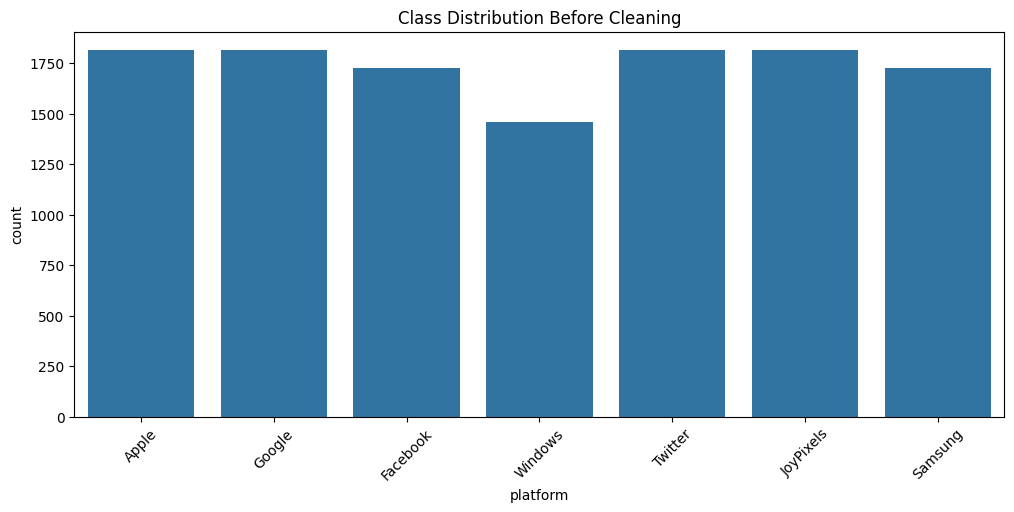

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

sns.countplot(
    x=metadata_df["platform"]
)

plt.title("Class Distribution Before Cleaning")
plt.xticks(rotation=45)
plt.show()

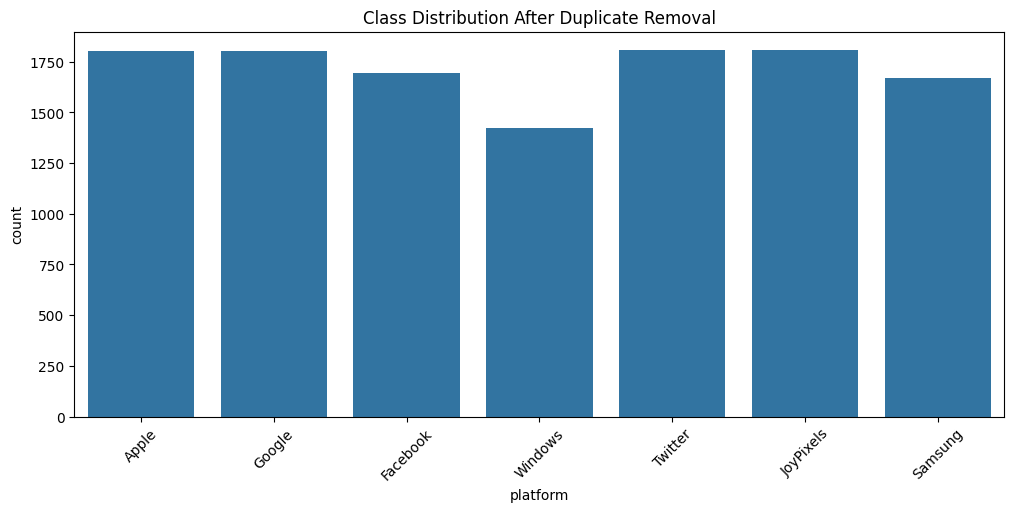

In [19]:
plt.figure(figsize=(12,5))

sns.countplot(
    x=clean_hash_df["platform"]
)

plt.title("Class Distribution After Duplicate Removal")
plt.xticks(rotation=45)
plt.show()

In [20]:
print("Original:", len(hash_df))
print("After duplicate removal:", len(clean_hash_df))

Original: 12169
After duplicate removal: 12001
